# FairLens — Auditing an Income Classifier for Demographic Bias
### AI For Good Hackathon · ACM-W Data Science Ethics track

**The question:** machine-learning models increasingly decide who gets a loan, an interview, or a benefit. They are optimized for *accuracy* — but accuracy says nothing about *fairness*. A model can be 87% accurate and still systematically deny opportunities to women or to a racial group.

In this notebook we:
1. clean the **UCI Adult / Census Income** dataset,
2. train a strong income classifier,
3. **audit** it for bias by `sex` and `race` using formal fairness metrics,
4. apply a **mitigation** and measure the (small) accuracy cost of fairness.

> The interactive version of these results lives in the FairLens dashboard (`streamlit run app.py`).

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from src.pipeline import (load_and_clean, train_model, fairness_block,
                          perf_metrics, NUMERIC, CATEGORICAL, SENSITIVE)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .25})

## 1. Load & clean the data

The raw Adult dataset encodes missing values inconsistently (whitespace, `?`, and true `NaN`). A subtle but common bug is to call `.str.strip()` *before* handling nulls, which turns `NaN` into the literal string `'nan'` and hides the missingness. Our pipeline normalizes all of these to a single `NaN`, then imputes categorical gaps with the column mode (keeping all 48,842 rows). We also drop two columns:
- `fnlwgt` — a survey sampling weight, not a person-level signal;
- `education` — redundant with the ordinal `education-num`.

In [2]:
df, report = load_and_clean()
print(f"rows: {report['rows_raw']:,} raw -> {report['rows_clean']:,} clean")
print(f"rows with >=1 missing value: {report['rows_with_any_missing']:,}")
pd.Series(report['missing_by_col'], name='missing_count').to_frame()

rows: 48,842 raw -> 48,842 clean
rows with >=1 missing value: 3,620


,missing_count
occupation,2809
workclass,2799
native-country,857


## 2. The data is *already* unequal

Before we train anything, the ground-truth positive rate (share earning >\$50k) differs sharply across groups. A model trained naively will learn — and often *amplify* — this historical inequality.

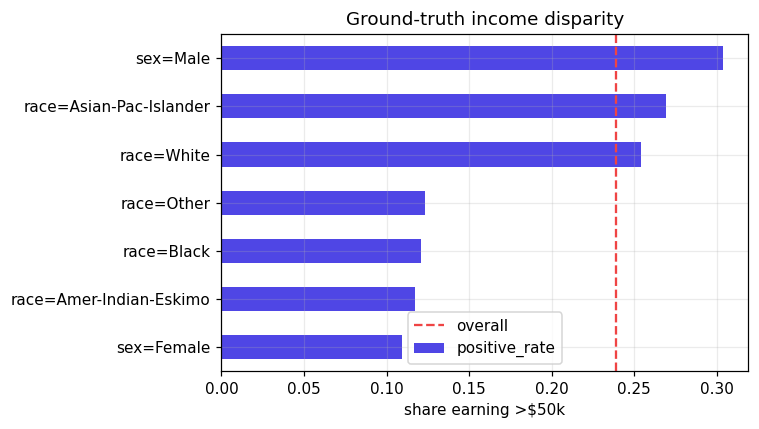

In [3]:
rates = pd.DataFrame({
    'positive_rate': {**{f'sex={k}': v for k,v in report['positive_rate_by_sex'].items()},
                      **{f'race={k}': v for k,v in report['positive_rate_by_race'].items()}}
})
ax = rates.sort_values('positive_rate').plot.barh(legend=False, color='#4F46E5', figsize=(7,4))
ax.axvline(report['positive_rate_overall'], color='#EF4444', ls='--', label='overall')
ax.set_xlabel('share earning >$50k'); ax.set_title('Ground-truth income disparity'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Train the classifier

A `HistGradientBoostingClassifier` on one-hot-encoded features. We hold out 30% of the data for evaluation. This is a genuinely strong model — the point is that strength and fairness are independent.

In [4]:
clf, X_train, X_test, y_train, y_test = train_model(df)
y_score = clf.predict_proba(X_test)[:, 1]
y_pred = (y_score >= 0.5).astype(int)
perf = perf_metrics(y_test, y_pred, y_score)
pd.Series(perf, name='baseline').to_frame()

,baseline
accuracy,0.8761
precision,0.7866
recall,0.6614
f1,0.7186
roc_auc,0.9296


## 4. Audit for bias

We use [Fairlearn](https://fairlearn.org/) to compute, per group:
- **selection rate** — how often the model predicts 'high income';
- **true / false positive rate** — does the model give equal *chances* and make equal *mistakes* across groups?

Summary metrics:
- **Disparate-impact ratio** = least-selected group's rate ÷ most-selected. The U.S. EEOC's **four-fifths rule** flags any ratio **< 0.80** as evidence of *adverse impact*.
- **Equalized-odds difference** — the largest gap in TPR/FPR across groups (0 = perfectly equal error rates).

In [5]:
for attr in SENSITIVE:
    fb = fairness_block(y_test, y_pred, X_test[attr])
    print(f'\n=== {attr.upper()} ===')
    print('disparate-impact ratio :', fb['disparate_impact_ratio'],
          '  (four-fifths rule: PASS)' if fb['disparate_impact_ratio']>=0.8 else '  (four-fifths rule: FAIL)')
    print('equalized-odds gap     :', fb['equalized_odds_difference'])
    display(pd.DataFrame(fb['by_group']))


=== SEX ===
disparate-impact ratio : 0.3221   (four-fifths rule: FAIL)
equalized-odds gap     : 0.0811


,sex,selection_rate,true_positive_rate,false_positive_rate,accuracy,count
0,Female,0.0836,0.5931,0.0181,0.9376,4857.0
1,Male,0.2595,0.6742,0.0805,0.8455,9796.0



=== RACE ===
disparate-impact ratio : 0.2051   (four-fifths rule: FAIL)
equalized-odds gap     : 0.3854


,race,selection_rate,true_positive_rate,false_positive_rate,accuracy,count
0,Amer-Indian-Eskimo,0.0507,0.2857,0.0085,0.8841,138.0
1,Asian-Pac-Islander,0.2473,0.6457,0.0958,0.8330,461.0
2,Black,0.0877,0.5691,0.0171,0.9300,1471.0
3,Other,0.0625,0.4286,0.0175,0.9219,128.0
4,White,0.2160,0.6711,0.0615,0.8707,12455.0


Both attributes **fail the four-fifths rule** by a wide margin. Women are selected at roughly a third of men's rate; the least-selected racial group at about a fifth of the most-selected. Even where accuracy looks fine, the *errors are unequally distributed* — that is the ethical harm.

## 5. Mitigation — and the cost of fairness

We apply Fairlearn's **`ThresholdOptimizer`**, a post-processing method that chooses *group-specific* decision thresholds to satisfy **equalized odds** while maximizing accuracy. Crucially, this requires no retraining and works on top of the existing model.

In [6]:
from fairlearn.postprocessing import ThresholdOptimizer
summary = []
for attr in SENSITIVE:
    topt = ThresholdOptimizer(estimator=clf, constraints='equalized_odds',
                              objective='accuracy_score', predict_method='predict_proba', prefit=True)
    topt.fit(X_train, y_train, sensitive_features=X_train[attr])
    y_mit = topt.predict(X_test, sensitive_features=X_test[attr])
    b = fairness_block(y_test, y_pred, X_test[attr])
    m = fairness_block(y_test, y_mit, X_test[attr])
    mp = perf_metrics(y_test, y_mit, y_score)
    summary.append({'attribute': attr,
                    'DI before': b['disparate_impact_ratio'], 'DI after': m['disparate_impact_ratio'],
                    'eq-odds before': b['equalized_odds_difference'], 'eq-odds after': m['equalized_odds_difference'],
                    'accuracy before': perf['accuracy'], 'accuracy after': mp['accuracy']})
pd.DataFrame(summary)

,attribute,DI before,DI after,eq-odds before,eq-odds after,accuracy before,accuracy after
0,sex,0.3221,0.4890,0.0811,0.0368,0.8761,0.8623
1,race,0.2051,0.4669,0.3854,0.0660,0.8761,0.8721


## 6. Takeaways

- A model can be **highly accurate and clearly discriminatory at the same time** — accuracy is not a fairness guarantee.
- Bias here is **measurable** with standard, legally-grounded metrics (four-fifths rule, equalized odds), not a matter of opinion.
- Mitigation **closes most of the gap for a few accuracy points** — fairness is affordable, but it is a deliberate choice someone has to make.
- 'Fairness through unawareness' (just dropping `sex`/`race`) does **not** work, because proxies like `relationship` and `marital-status` re-encode the protected attribute.

**FairLens turns this audit into a tool anyone can use** — explore it live in the dashboard.